# 03 — Baseline: scoring every pair on its own

The standard approach in metabologenomics is to test each BGC–metabolite pair independently for
association across strains and keep the ones that come out significant. This notebook implements
that baseline and then measures the two ways it fails.

**It consumes only the masked graph.** The ground truth is loaded for evaluation and never enters
the test itself.

## What the test asks

For one BGC $i$ and one metabolite $j$, tabulate the strains four ways — carries $i$ or not,
against produces $j$ or not — and ask whether the two are independent with Fisher's exact test. A
strong association means the BGC tends to be present exactly in the strains that make the compound.

## Why it is not enough

Two problems follow from scoring pairs one at a time, and both are quantified below rather than
asserted.

1. **Impossible links.** Nothing stops the test from reporting a pair where some strain produces
   the metabolite without carrying the BGC. Such a link cannot appear in any valid assignment.
2. **Global inconsistency.** A BGC can be credited with many metabolites and a metabolite with many
   BGCs, so the reported set of links need not be jointly realizable.

A third, separate issue is that strains are related by descent rather than independent samples,
which inflates significance. The permutation control in Part 5 gives a handle on that.

In [1]:
try:                       # inline figures in Jupyter; a plain script has no IPython,
    get_ipython().run_line_magic("matplotlib", "inline")   # so fall back to a
except NameError:                                          # headless backend
    import matplotlib
    matplotlib.use("Agg")
import json
import math
from collections import Counter
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import fisher_exact

# publication-ready defaults, matching notebook 01
sns.set_theme(style="white", context="talk", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "axes.grid": False, "xtick.bottom": False, "ytick.left": False,
    "legend.frameon": False,
})

# ----------------------------------------------------------------- configuration
SEED = 0                # everything random below derives from this
ALPHA = 0.05            # significance level; lowering it shrinks the predicted graph
N_TIE_RUNS = 100        # random tie-break repetitions for the ranking in Part 6
N_PERMUTATIONS = 10     # permutation controls in Part 5; more gives a tighter mean
K_PLOT_MAX = 500        # right edge of the recall@k plot; recall has saturated well
                        # before this, so a larger value only adds empty axis

_MUTED = sns.color_palette("muted")
COLORS = {"microbe": _MUTED[0], "family": _MUTED[3], "molecule": _MUTED[1],
          "true": _MUTED[2], "false": "#c9ccd3", "baseline": _MUTED[4]}
WRITTEN = []

REPO_ROOT = Path("..").resolve()
DATASET   = "dataset1_streptomyces"   # subfolder of data/ written by notebook 01
DATA_DIR  = REPO_ROOT / "data" / DATASET
OUT_DIR   = REPO_ROOT / "output" / "03_streptomyces_baseline"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRUTH_JSON  = DATA_DIR / "ground_truth_metabologenomics_graph.json"
MASKED_JSON = DATA_DIR / "masked_metabologenomics_graph.json"
for p in (TRUTH_JSON, MASKED_JSON):
    if not p.exists():
        raise FileNotFoundError(f"{p.name} missing - run notebook 01 first.")

rng = np.random.default_rng(SEED)
print(f"input : {DATA_DIR.relative_to(REPO_ROOT)}/")
print(f"output: {OUT_DIR.relative_to(REPO_ROOT)}/")

input : data/dataset1_streptomyces/
output: output/03_streptomyces_baseline/


## 1. Load the data

The masked graph gives the two binary matrices the test needs: `B` recording which strain carries
which BGC, and `M` recording which strain produces which metabolite. The ground truth supplies the
set of correct pairs, used only to score the result.

In [2]:
def load_graph(path):
    data = json.loads(path.read_text())
    try:
        return nx.node_link_graph(data, edges="links")
    except TypeError:
        return nx.node_link_graph(data)


G_masked = load_graph(MASKED_JSON)
G_truth = load_graph(TRUTH_JSON)

strains = sorted(n for n, d in G_masked.nodes(data=True) if d["ntype"] == "microbe")
bgcs = sorted(n for n, d in G_masked.nodes(data=True) if d["ntype"] == "family")
mols = sorted(n for n, d in G_masked.nodes(data=True) if d["ntype"] == "molecule")
si = {s: k for k, s in enumerate(strains)}
bi = {b: k for k, b in enumerate(bgcs)}
mi = {m: k for k, m in enumerate(mols)}

B = np.zeros((len(strains), len(bgcs)), dtype=int)
M = np.zeros((len(strains), len(mols)), dtype=int)
for u, v, d in G_masked.edges(data=True):
    a, b = (u, v) if G_masked.nodes[u]["ntype"] == "microbe" else (v, u)
    if d["etype"] == "carries":
        B[si[a], bi[b]] = 1
    else:
        M[si[a], mi[b]] = 1

# evaluation only, never used to compute a p-value
true_pairs = set()
for u, v, d in G_truth.edges(data=True):
    if d["etype"] != "produces":
        continue
    f, m = (u, v) if G_truth.nodes[u]["ntype"] == "family" else (v, u)
    true_pairs.add((f, m))

N_s, N_b, N_m = len(strains), len(bgcs), len(mols)
assert B.shape == (N_s, N_b) and M.shape == (N_s, N_m)
assert all(f in bi and m in mi for f, m in true_pairs), "ground truth node missing from masked graph"
print(f"strains {N_s} | BGCs {N_b} | metabolites {N_m}")
print(f"B density {B.mean():.1%} | M density {M.mean():.1%}")
print(f"true links {len(true_pairs)} out of {N_b * N_m:,} possible pairs "
      f"({len(true_pairs) / (N_b * N_m):.2%})")

strains 62 | BGCs 96 | metabolites 78
B density 11.8% | M density 9.8%
true links 78 out of 7,488 possible pairs (1.04%)


## 2. Test every pair

The four cell counts follow from three numbers, so the whole $N^b \times N^m$ grid of contingency
tables comes from one matrix product.

Both matrices are sparse, so almost every table has expected cell counts below five, where the
$\chi^2$ approximation does not hold. We therefore use **Fisher's exact test** throughout. It is
exact at any sparsity and keeps every p-value on one scale, which matters because the evaluation in
Part 6 is a ranking. The price is that Fisher is conservative for $2 \times 2$ tables, since
conditioning on both margins coarsens the achievable significance levels, so the predicted graph is
if anything smaller than a less careful test would give.

We use the **one-sided** test in the positive direction. Only a positive association is evidence
that a BGC makes a metabolite. A BGC present in exactly the strains where the metabolite is absent
is perfectly anti-correlated with it, which is as far from independence as perfect correlation, so a
two-sided test would score that pair like a real link. The one-sided test is therefore the fairer
baseline, not the weaker one.

In [3]:
n_i = B.sum(0)                       # strains carrying each BGC
n_j = M.sum(0)                       # strains producing each metabolite
co = B.T @ M                         # strains doing both

rows = []
for x, y in product(range(N_b), range(N_m)):
    a = co[x, y]                     # carries and produces
    b = n_i[x] - a                   # carries, does not produce
    c = n_j[y] - a                   # produces, does not carry  -> impossible if > 0
    d = N_s - a - b - c
    exp_min = np.outer([a + b, c + d], [a + c, b + d]).min() / N_s
    # one-sided: only a positive association is evidence for a link. A BGC present
    # exactly where the metabolite is absent is perfect anti-correlation, which a
    # two-sided test would score like perfect correlation.
    p = fisher_exact([[a, b], [c, d]], alternative="greater")[1]
    rows.append((bgcs[x], mols[y], a, b, c, d, exp_min, p))

pairs = pd.DataFrame(rows, columns=["bgc", "molecule", "n11", "n10", "n01", "n00",
                                    "min_expected", "p_value"])
pairs["is_true_link"] = [(r.bgc, r.molecule) in true_pairs for r in pairs.itertuples()]
pairs["impossible"] = pairs["n01"] > 0        # a producer lacking the BGC

print(f"tables with a expected cell count below 5: {(pairs['min_expected'] < 5).mean():.0%} "
      f"- which is why the chi-squared approximation is unusable here")
print(f"distinct p-values: {pairs['p_value'].nunique():,} for {len(pairs):,} pairs "
      f"(Fisher is discrete, so ties are common)")
print(f"pairs that no valid assignment could contain: {pairs['impossible'].mean():.0%}")

tables with a expected cell count below 5: 98% - which is why the chi-squared approximation is unusable here


distinct p-values: 630 for 7,488 pairs (Fisher is discrete, so ties are common)
pairs that no valid assignment could contain: 90%


## 3. The predicted graph

Both corrections are reported, and Benjamini–Hochberg is used downstream as the less conservative
of the two.

In [4]:
def bonferroni(p):
    return np.minimum(p * len(p), 1.0)


def benjamini_hochberg(p):
    m = len(p)
    order = np.argsort(p)
    ranked = p[order] * m / np.arange(1, m + 1)
    adj = np.minimum.accumulate(ranked[::-1])[::-1]      # enforce monotonicity
    out = np.empty(m)
    out[order] = np.minimum(adj, 1.0)
    return out


p = pairs["p_value"].to_numpy()
pairs["p_bonferroni"] = bonferroni(p)
pairs["p_bh"] = benjamini_hochberg(p)

for col in ("p_bonferroni", "p_bh"):
    sig = pairs[pairs[col] <= ALPHA]
    print(f"{col:14s}: {len(sig):5,} significant pairs | "
          f"{sig['bgc'].nunique():3d} BGCs | {sig['molecule'].nunique():3d} metabolites | "
          f"{sig['is_true_link'].sum():3d} true "
          f"({sig['is_true_link'].sum() / max(len(true_pairs), 1):.0%} of ground truth recovered)")

pairs["significant"] = pairs["p_bh"] <= ALPHA
predicted = pairs[pairs["significant"]].copy()

# the full ranking of every possible edge, most significant first. Fisher is
# discrete, so many pairs share a p-value; rank_min gives every member of a tie
# the best rank in its block, rank_avg the average, and tie_size its width
pairs = pairs.sort_values(["p_value", "bgc", "molecule"]).reset_index(drop=True)
pairs.insert(0, "rank_min", pairs["p_value"].rank(method="min").astype(int))
pairs.insert(1, "rank_avg", pairs["p_value"].rank(method="average"))
pairs.insert(2, "tie_size", pairs.groupby("p_value")["p_value"].transform("size"))

RANK_CSV = OUT_DIR / "part3_ranked_pairs.csv"
pairs.to_csv(RANK_CSV, index=False)
WRITTEN.append(RANK_CSV)
print(f"\nwrote {RANK_CSV.name}: all {len(pairs):,} pairs ranked by significance")
print(pairs.loc[:7, ["rank_min", "tie_size", "bgc", "molecule",
                     "p_value", "p_bh", "is_true_link", "impossible"]]
      .to_string(index=False))

p_bonferroni  :    23 significant pairs |  20 BGCs |  20 metabolites |  20 true (26% of ground truth recovered)
p_bh          :    51 significant pairs |  41 BGCs |  40 metabolites |  40 true (51% of ground truth recovered)

wrote part3_ranked_pairs.csv: all 7,488 pairs ranked by significance
 rank_min  tie_size          bgc                           molecule      p_value         p_bh  is_true_link  impossible
        1         1 BGC0000325.5                        coelichelin 6.702597e-14 5.018905e-10          True       False
        2         1 BGC0000664.5                     isorenieratene 2.500739e-11 9.362767e-08          True       False
        3         1 BGC0000908.3                            melanin 4.548382e-11 1.135276e-07          True       False
        4         1 BGC0000940.5 desferrioxamin B/desferrioxamine E 8.655315e-11 1.620275e-07          True       False
        5         1 BGC0000271.5                      spore pigment 1.084614e-10 1.624318e-07          Tru

## 4. Why independent scoring fails

Three measurements, matching the three claims made about this baseline.

In [5]:
# 1. links that violate the validity condition outright
imp = predicted["impossible"].sum()
print(f"1. impossible links among the predictions: {imp} of {len(predicted)} "
      f"({imp / max(len(predicted), 1):.0%})")
print(f"   of the true links, {predicted.query('is_true_link')['impossible'].sum()} are impossible")

# 2. how many partners each side is credited with
per_bgc = predicted.groupby("bgc").size()
per_mol = predicted.groupby("molecule").size()
print(f"\n2. metabolites credited per BGC : median {per_bgc.median():.0f}, "
      f"max {per_bgc.max()} (the idealized model allows 1)")
print(f"   BGCs credited per metabolite  : median {per_mol.median():.0f}, "
      f"max {per_mol.max()}")

# 3. can the predictions hold simultaneously?
H = nx.Graph()
H.add_nodes_from(predicted["bgc"].unique(), bipartite=0)
H.add_nodes_from(predicted["molecule"].unique(), bipartite=1)
H.add_edges_from(zip(predicted["bgc"], predicted["molecule"]))
matching = nx.algorithms.bipartite.maximum_matching(H, top_nodes=set(predicted["bgc"].unique()))
m_size = len(matching) // 2
n_mol_pred = predicted["molecule"].nunique()
print(f"\n3. metabolites with a prediction : {n_mol_pred}")
print(f"   largest jointly realizable set: {m_size}")
print(f"   predictions that cannot hold simultaneously: {n_mol_pred - m_size}")
if n_mol_pred == m_size:
    print("   NOTE: on this dataset the predicted links happen to be jointly")
    print("   realizable, so global inconsistency does not bite here.")

DIAG_CSV = OUT_DIR / "part4_diagnostics.csv"
pd.DataFrame([
    {"quantity": "predicted_links", "value": len(predicted)},
    {"quantity": "impossible_links", "value": int(imp)},
    {"quantity": "max_metabolites_per_bgc", "value": int(per_bgc.max())},
    {"quantity": "max_bgcs_per_metabolite", "value": int(per_mol.max())},
    {"quantity": "metabolites_predicted", "value": int(n_mol_pred)},
    {"quantity": "jointly_realizable", "value": int(m_size)},
]).to_csv(DIAG_CSV, index=False)
WRITTEN.append(DIAG_CSV)

1. impossible links among the predictions: 7 of 51 (14%)
   of the true links, 0 are impossible

2. metabolites credited per BGC : median 1, max 3 (the idealized model allows 1)
   BGCs credited per metabolite  : median 1, max 3

3. metabolites with a prediction : 40
   largest jointly realizable set: 40
   predictions that cannot hold simultaneously: 0
   NOTE: on this dataset the predicted links happen to be jointly
   realizable, so global inconsistency does not bite here.


## 5. Permutation control

Shuffling which strain has which metabolite profile destroys any real BGC–metabolite association
while leaving both sets of marginals intact. A well-calibrated test should return almost nothing.
Whatever survives is significance manufactured by the structure of the strain collection.

In [6]:
def run_test(M_perm):
    co_p = B.T @ M_perm
    nj_p = M_perm.sum(0)
    out = np.empty(N_b * N_m)
    k = 0
    for x, y in product(range(N_b), range(N_m)):
        a = co_p[x, y]
        b = n_i[x] - a
        c = nj_p[y] - a
        d = N_s - a - b - c
        out[k] = fisher_exact([[a, b], [c, d]], alternative="greater")[1]
        k += 1
    return out


perm_rows = []
for r in range(N_PERMUTATIONS):
    perm = np.random.default_rng(SEED + r).permutation(N_s)
    p_perm = run_test(M[perm])
    n_sig = int((benjamini_hochberg(p_perm) <= ALPHA).sum())
    perm_rows.append({"run": r, "n_significant": n_sig})
    print(f"  permutation {r}: {n_sig:5,} significant pairs", end="\r")

perm = pd.DataFrame(perm_rows)
print(f"\npermuted data: {perm['n_significant'].mean():.0f} significant pairs on average "
      f"(range {perm['n_significant'].min()}-{perm['n_significant'].max()})")
print(f"real data    : {len(predicted):,} significant pairs")

PERM_CSV = OUT_DIR / "part5_permutation_control.csv"
perm.to_csv(PERM_CSV, index=False)
WRITTEN.append(PERM_CSV)

  permutation 9:     0 significant pairs
permuted data: 0 significant pairs on average (range 0-0)
real data    : 51 significant pairs


## 6. Where do the true links rank?

Ordering all pairs by p-value gives a ranking that can be compared against \textsc{Cupid}, which
orders by support. Ties are broken uniformly at random and the whole procedure repeated, so the
reported rank does not depend on one arbitrary ordering.

In [7]:
p_all = pairs["p_value"].to_numpy()
is_true = pairs["is_true_link"].to_numpy()
true_idx = np.flatnonzero(is_true)
labels = [f"{r.bgc} -> {r.molecule}" for r in pairs.itertuples()]

rank_rows = []
for r in range(N_TIE_RUNS):
    jitter = np.random.default_rng(SEED + r).permutation(len(p_all))
    order = np.lexsort((jitter, p_all))          # ties broken at random
    rank = np.empty(len(p_all), dtype=int)
    rank[order] = np.arange(1, len(p_all) + 1)
    for k in true_idx:
        rank_rows.append({"run": r, "pair": labels[k], "rank": int(rank[k])})

ranks = pd.DataFrame(rank_rows)
per_run_median = ranks.groupby("run")["rank"].median()
print(f"median rank of a true link: {per_run_median.mean():.1f} "
      f"(IQR over pairs {ranks['rank'].quantile(0.25):.0f}-{ranks['rank'].quantile(0.75):.0f})")
print(f"out of {len(p_all):,} pairs; a random ordering would give {len(p_all) / 2:,.0f}")
print(f"true links in the top 100: "
      f"{(ranks.groupby('pair')['rank'].mean() <= 100).sum()} of {len(true_idx)}")

RANKS_CSV = OUT_DIR / "part6_ranks.csv"
ranks.to_csv(RANKS_CSV, index=False)
WRITTEN.append(RANKS_CSV)
print(f"\nwrote {RANKS_CSV.name} for the comparison in notebook 02")

median rank of a true link: 49.0 (IQR over pairs 21-99)
out of 7,488 pairs; a random ordering would give 3,744
true links in the top 100: 60 of 78

wrote part6_ranks.csv for the comparison in notebook 02


### Recall at k

A median rank summarizes the ranking with one number and hides the shape of it. The quantity that
matches the decision a biologist actually makes is recall@k, the fraction of the true links found
after assaying the k best-scoring candidates, so k is an experimental budget.

Precision@k carries no extra information here, since the number of true links P is fixed and
`precision@k = recall@k * P / k`; it is recorded in the CSV but not plotted. Accuracy is useless at
this prevalence, roughly 1%, because predicting nothing already scores 99%, and ROC-AUC is
dominated by the thousands of true negatives. The single-number summary is instead the average
precision, the mean of the precision at the rank of each true link, which is the area under the
precision-recall curve and has a random-ranking value of P/N.

In [8]:
def recall_at_k(score, is_true, n_runs=N_TIE_RUNS, seed=SEED, descending=False):
    # Both scores here are heavily tied - Fisher's test is discrete, and Cupid's support is
    # quantized by the number of samples - so a tie block straddling k would make the curve
    # depend on input order. Every run breaks ties uniformly at random and the whole curve is
    # recomputed, giving a mean and a min-max band rather than one arbitrary trace.
    key = -np.asarray(score, dtype=float) if descending else np.asarray(score, dtype=float)
    N, P = len(key), int(is_true.sum())
    hits = np.empty((n_runs, N))
    aps = np.empty(n_runs)
    for r in range(n_runs):
        jitter = np.random.default_rng(seed + r).permutation(N)
        y = is_true[np.lexsort((jitter, key))]
        tp = np.cumsum(y)
        hits[r] = tp
        aps[r] = (tp / np.arange(1, N + 1))[y].mean()   # average precision
    k = np.arange(1, N + 1)
    curve = pd.DataFrame({
        "k": k,
        "hits_mean": hits.mean(0), "hits_lo": hits.min(0), "hits_hi": hits.max(0),
        "recall_mean": hits.mean(0) / P,
        "recall_lo": hits.min(0) / P, "recall_hi": hits.max(0) / P,
        "precision_mean": hits.mean(0) / k,
        "enrichment_mean": (hits.mean(0) / k) / (P / N),
        "recall_random": k / N,
    })
    return curve, aps


curve, aps = recall_at_k(p_all, is_true)
AP, AP_SD = aps.mean(), aps.std()
P_RATE = is_true.mean()
curve.to_csv(OUT_DIR / "part6_recall_at_k.csv", index=False)
WRITTEN.append(OUT_DIR / "part6_recall_at_k.csv")

print(f"average precision: {AP:.3f} (sd {AP_SD:.4f} over {N_TIE_RUNS} runs; "
      f"random ranking gives {P_RATE:.4f})\n")
print(f"{'k':>5}{'hits':>7}{'recall':>9}{'precision':>11}{'enrichment':>12}")
for k_ in (10, 25, 50, len(true_idx), 100, 200, 500):
    r_ = curve.iloc[k_ - 1]
    print(f"{k_:>5}{r_.hits_mean:>7.1f}{r_.recall_mean:>9.2f}"
          f"{r_.precision_mean:>11.2f}{r_.enrichment_mean:>11.0f}x")

average precision: 0.710 (sd 0.0008 over 100 runs; random ranking gives 0.0104)

    k   hits   recall  precision  enrichment
   10   10.0     0.13       1.00         96x
   25   22.0     0.28       0.88         84x
   50   39.0     0.50       0.78         75x
   78   52.0     0.67       0.67         64x
  100   58.9     0.76       0.59         57x
  200   63.9     0.82       0.32         31x
  500   74.0     0.95       0.15         14x


## 7. Figures

In [9]:
def save_fig(fig, name, data=None):
    for ext in ("jpg", "pdf"):
        p_ = OUT_DIR / f"{name}.{ext}"
        fig.savefig(p_)
        WRITTEN.append(p_)
    if data is not None:
        p_ = OUT_DIR / f"{name}.csv"
        data.to_csv(p_, index=False)
        WRITTEN.append(p_)


# same three-row layout as notebook 01, so the figures can be read side by side:
# an anchor row placed by degree, the others at their neighbours' barycentre
def layered_pos(H, rows, anchor):
    ys = {t: 1.0 - i for i, t in enumerate(rows)}
    pos = {}
    anch = sorted([n for n, d in H.nodes(data=True) if d["ntype"] == anchor],
                  key=lambda n: (-H.degree(n), str(n)))
    d0 = max(len(anch) - 1, 1)
    for i, n in enumerate(anch):
        pos[n] = (i / d0, ys[anchor])
    for t in rows:
        if t == anchor:
            continue
        members = sorted([n for n, dd in H.nodes(data=True) if dd["ntype"] == t], key=str)
        bary = {n: np.mean([pos[v][0] for v in H.neighbors(n) if v in pos] or [0.5])
                for n in members}
        ranked = sorted(members, key=lambda n: (bary[n], str(n)))
        d1 = max(len(ranked) - 1, 1)
        for i, n in enumerate(ranked):
            pos[n] = (i / d1, ys[t])
    return pos


ROWS = ["microbe", "family", "molecule"]
# how each BGC-metabolite edge is drawn, by whether the test found it and
# whether it is real
# the two error classes are what the figure is for, so they sit on top and stay
# opaque; the correct predictions recede into the background
STYLE = {
    "true positive":  dict(color=_MUTED[2], lw=1.8, ls="-",  alpha=0.40, z=2),
    "false positive": dict(color=_MUTED[4], lw=1.7, ls="-",  alpha=0.90, z=4),
    "false negative": dict(color="#333333", lw=1.6, ls="--", alpha=0.90, z=5),
}

pred_pairs = set(zip(predicted["bgc"], predicted["molecule"]))
edge_class = {}
for e in pred_pairs | true_pairs:
    edge_class[e] = ("true positive" if e in pred_pairs and e in true_pairs
                     else "false positive" if e in pred_pairs else "false negative")


def plot_links(node_filter=None, title="", name="", figsize=(16, 7),
               carries_width=0.5, node_size=90):
    H = nx.Graph()
    for n in strains:
        H.add_node(n, ntype="microbe")
    for n in bgcs:
        H.add_node(n, ntype="family")
    for n in mols:
        H.add_node(n, ntype="molecule")
    for u, v, d in G_masked.edges(data=True):
        if d["etype"] == "carries":
            H.add_edge(u, v, etype="carries")
    for (f, m), cls in edge_class.items():
        H.add_edge(f, m, etype=cls)
    if node_filter is not None:
        H = H.subgraph(node_filter).copy()

    pos = layered_pos(H, ROWS, anchor="family")
    fig, ax = plt.subplots(figsize=figsize)
    for u, v, d in H.edges(data=True):          # carries first, underneath
        if d["etype"] != "carries":
            continue
        (x0, y0), (x1, y1) = pos[u], pos[v]
        ax.plot([x0, x1], [y0, y1], lw=carries_width, color="#b0b7c3",
                alpha=0.8, zorder=1)
    counts = Counter()
    for u, v, d in sorted(H.edges(data=True),
                          key=lambda e: STYLE.get(e[2]["etype"], {}).get("z", 0)):
        st = STYLE.get(d["etype"])
        if st is None:
            continue
        counts[d["etype"]] += 1
        (x0, y0), (x1, y1) = pos[u], pos[v]
        ax.plot([x0, x1], [y0, y1], lw=st["lw"], color=st["color"],
                ls=st["ls"], alpha=st["alpha"], zorder=st["z"])
    for t in ROWS:
        ns = [n for n, d in H.nodes(data=True) if d["ntype"] == t]
        ax.scatter([pos[n][0] for n in ns], [pos[n][1] for n in ns],
                   s=node_size, color=COLORS[t], zorder=5, linewidths=0)
        ax.text(-0.035, 1.0 - ROWS.index(t), t, ha="right", va="center",
                fontsize=13, color=COLORS[t], fontweight="bold")
    handles = [plt.Line2D([], [], color=STYLE[k]["color"], lw=STYLE[k]["lw"] + 0.6,
                          ls=STYLE[k]["ls"], alpha=1.0, label=f"{k} ({counts[k]})")
               for k in STYLE]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
              ncol=3, fontsize=11)
    ax.set_xlim(-0.18, 1.04)
    ax.axis("off")
    ax.set_title(title, fontsize=15)

    df = pd.DataFrame([{"bgc": u if H.nodes[u]["ntype"] == "family" else v,
                        "molecule": v if H.nodes[u]["ntype"] == "family" else u,
                        "edge_class": d["etype"],
                        "x_bgc": pos[u if H.nodes[u]["ntype"] == "family" else v][0],
                        "x_molecule": pos[v if H.nodes[u]["ntype"] == "family" else u][0]}
                       for u, v, d in H.edges(data=True) if d["etype"] in STYLE])
    save_fig(fig, name, df.sort_values(["edge_class", "bgc", "molecule"]))
    plt.show()
    return counts

### Predicted against true links

Three kinds of edge. Green where the test found a real link, purple where it invented one, and
dashed grey where it missed one. Grey `carries` edges give the same context as in notebook 01.

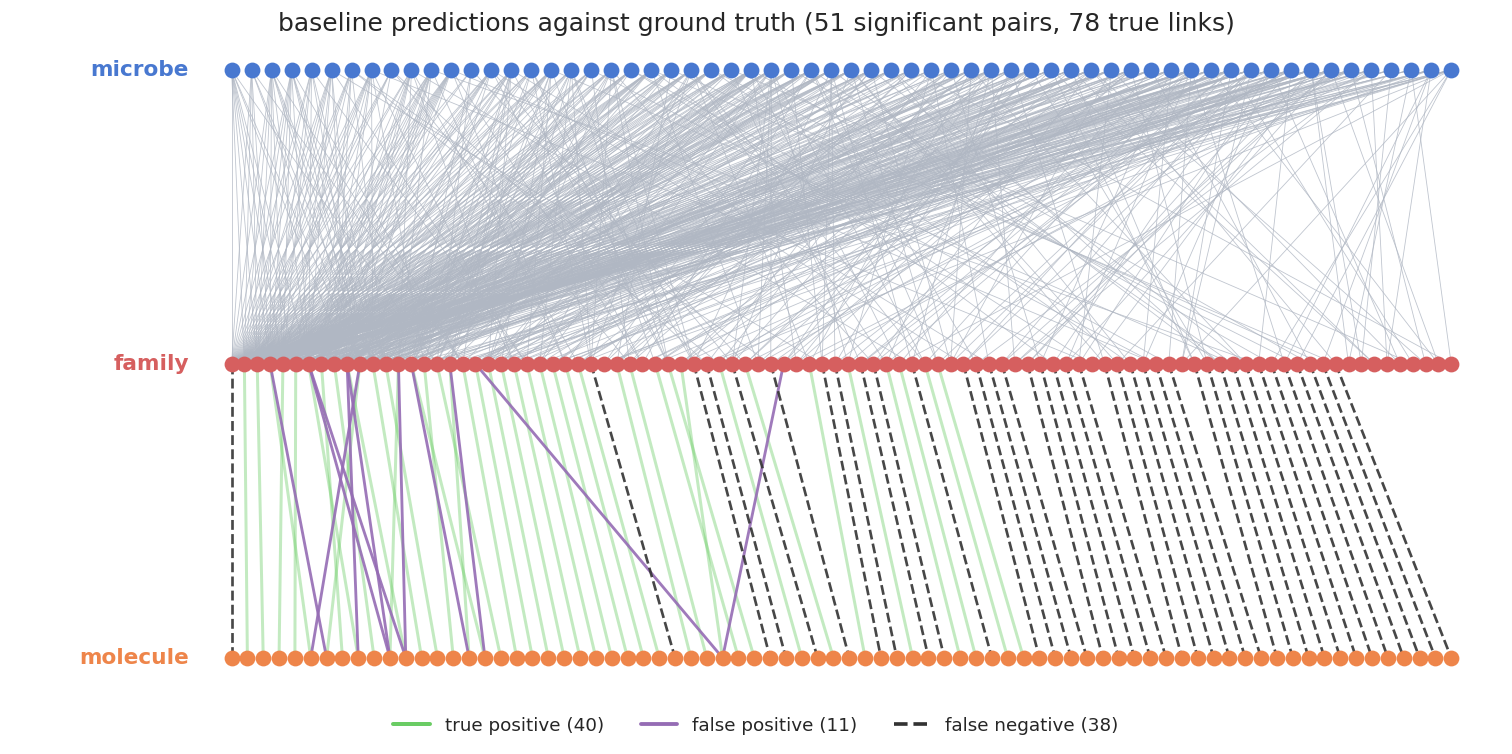

{'true positive': 40, 'false positive': 11, 'false negative': 38}


In [10]:
counts_full = plot_links(
    title=f"baseline predictions against ground truth "
          f"({len(predicted):,} significant pairs, {len(true_pairs)} true links)",
    name="part7_baseline_graph")
print({k: counts_full[k] for k in STYLE})

### The same slice as notebook 01

Restricted to the same genomes that notebook 01 draws, so the two figures line up.

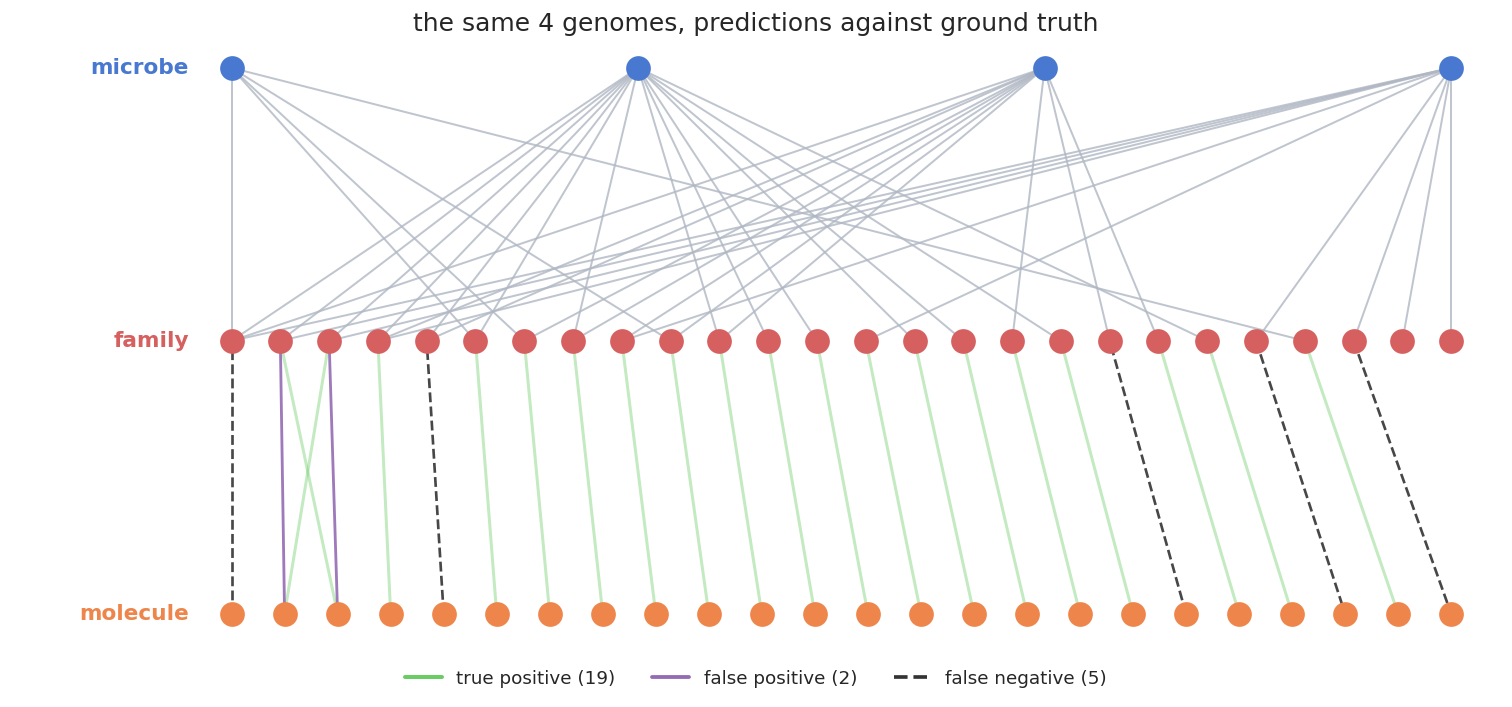

{'true positive': 19, 'false positive': 2, 'false negative': 5}


In [11]:
# identical selection to notebook 01: same seed, same sorted strain list
N_SUBSET_STRAINS, SUBSET_SEED = 4, 0
picked = sorted(np.random.default_rng(SUBSET_SEED)
                .choice(sorted(strains), size=N_SUBSET_STRAINS, replace=False).tolist())
keep = set(picked)
for m_ in picked:
    for f in G_truth.neighbors(m_):
        if G_truth.nodes[f]["ntype"] != "family":
            continue
        keep.add(f)
        keep.update(x for x in G_truth.neighbors(f)
                    if G_truth.nodes[x]["ntype"] == "molecule")

counts = plot_links(node_filter=keep, figsize=(16, 6.5),
                    carries_width=1.2, node_size=220,
                    title=f"the same {N_SUBSET_STRAINS} genomes, predictions against ground truth",
                    name="part7_baseline_graph_subset")
print({k: counts[k] for k in STYLE})

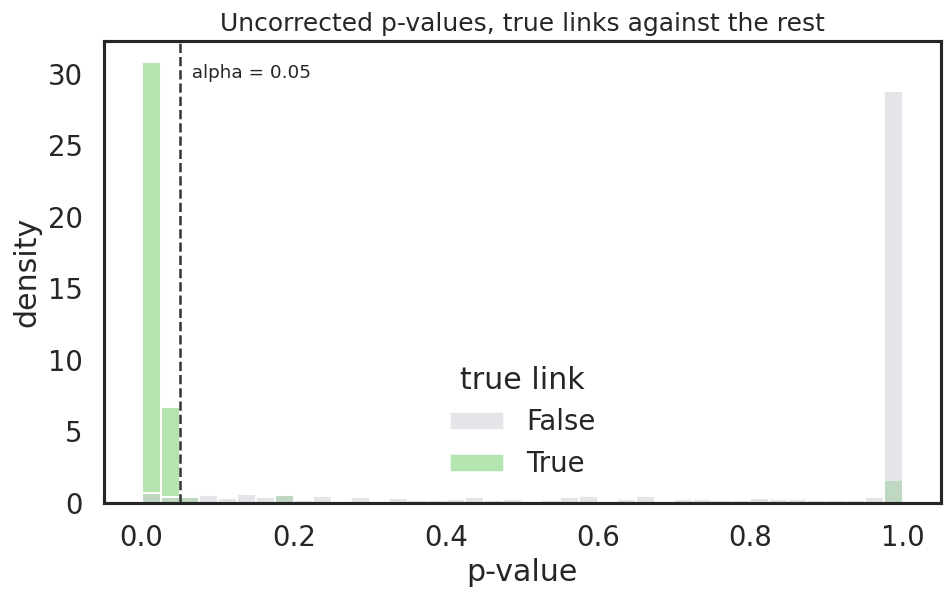

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 41)
sns.histplot(data=pairs, x="p_value", hue="is_true_link", bins=bins,
             multiple="layer", stat="density", common_norm=False,
             palette={False: COLORS["false"], True: COLORS["true"]}, ax=ax)
ax.axvline(ALPHA, color="#333333", ls="--", lw=1.5)
ax.text(ALPHA, ax.get_ylim()[1] * 0.95, f"  alpha = {ALPHA}", fontsize=11, va="top")
ax.set_xlabel("p-value")
ax.set_ylabel("density")
ax.set_title("Uncorrected p-values, true links against the rest", fontsize=15)
if ax.get_legend():
    ax.get_legend().set_title("true link")
save_fig(fig, "part7_pvalue_distribution",
         pairs[["bgc", "molecule", "p_value", "is_true_link"]])
plt.show()

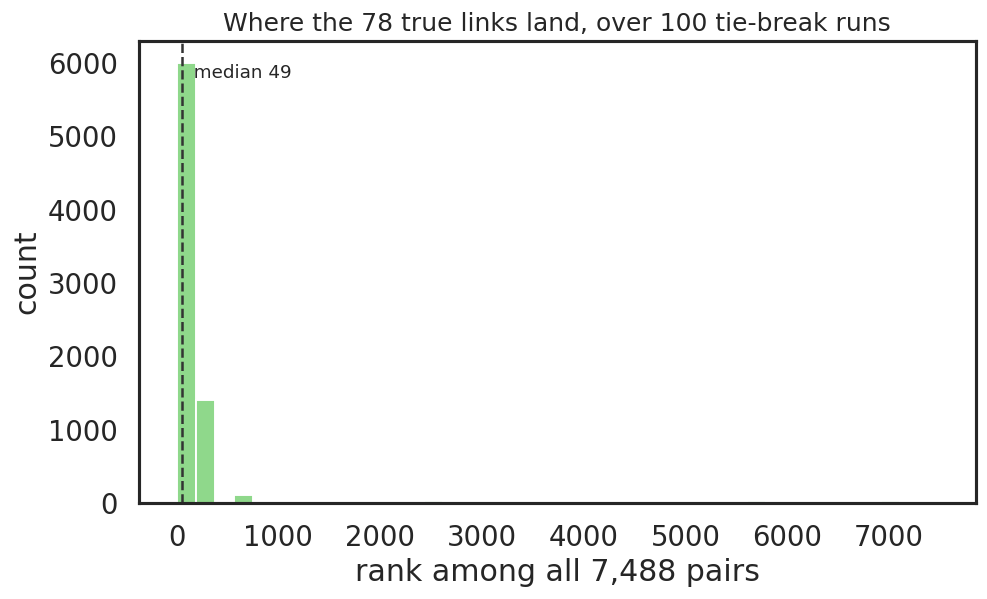

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(ranks["rank"], bins=40, color=COLORS["true"], ax=ax)
ax.axvline(per_run_median.mean(), color="#333333", ls="--", lw=1.5)
ax.text(per_run_median.mean(), ax.get_ylim()[1] * 0.95,
        f"  median {per_run_median.mean():.0f}", fontsize=11, va="top")
ax.set_xlabel(f"rank among all {len(p_all):,} pairs")
ax.set_ylabel("count")
ax.set_title(f"Where the {len(true_idx)} true links land, over "
             f"{N_TIE_RUNS} tie-break runs", fontsize=15)
save_fig(fig, "part7_rank_distribution", ranks)
plt.show()

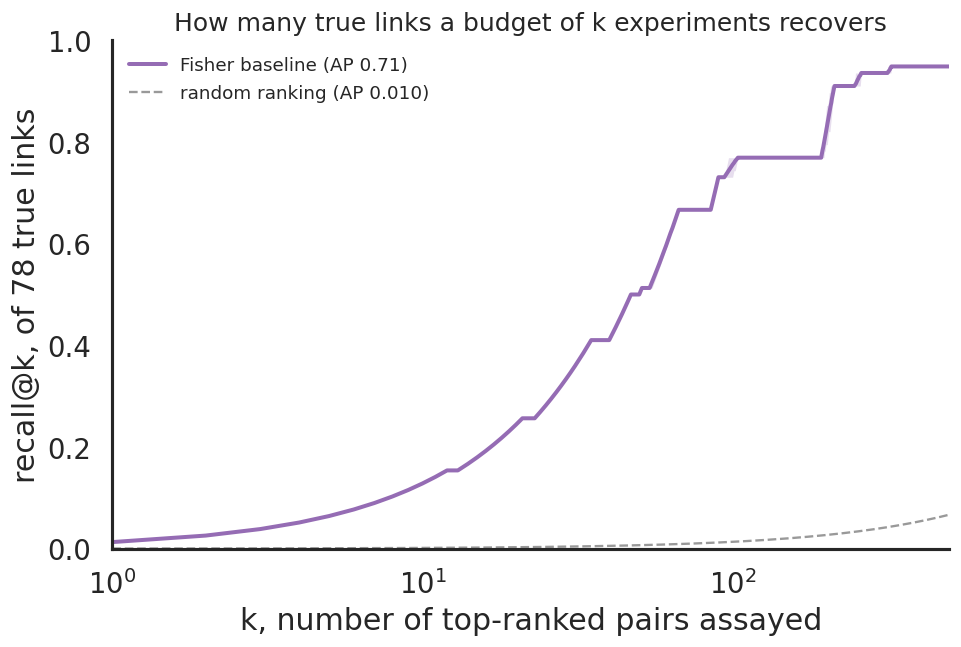

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sub = curve[curve["k"] <= K_PLOT_MAX]
ax.fill_between(sub["k"], sub["recall_lo"], sub["recall_hi"],
                color=COLORS["baseline"], alpha=0.22, lw=0)
ax.plot(sub["k"], sub["recall_mean"], color=COLORS["baseline"], lw=2.4,
        label=f"Fisher baseline (AP {AP:.2f})")
ax.plot(sub["k"], sub["recall_random"], color="#999999", lw=1.4, ls="--",
        label=f"random ranking (AP {P_RATE:.3f})")
ax.set_xscale("log")
ax.set_xlim(1, K_PLOT_MAX)
ax.set_ylim(0, 1)
ax.set_xlabel("k, number of top-ranked pairs assayed")
ax.set_ylabel(f"recall@k, of {len(true_idx)} true links")
ax.set_title("How many true links a budget of k experiments recovers", fontsize=15)
ax.legend(fontsize=11, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
save_fig(fig, "part7_recall_at_k", sub)
plt.show()

## 8. The toy example from the appendix

The same test applied to the small example used to introduce the notation. With only three strains
the test has almost no power, so this part reports every one of the $5 \times 4$ p-values rather than
a filtered list, and states the smallest value the test could possibly return at this sample size.

In [15]:
# the example of Appendix A, hard-coded so it stays readable beside the text
B_toy = np.array([[1, 1, 1, 0, 0],
                  [0, 1, 1, 0, 0],
                  [0, 0, 0, 1, 1]])
M_toy = np.array([[1, 1, 1, 0],
                  [0, 1, 1, 0],
                  [0, 0, 0, 1]])
ns_t, nb_t = B_toy.shape
nm_t = M_toy.shape[1]


def best_attainable_p(n):
    # smallest one-sided Fisher p-value reachable with n samples, over every pair of
    # margins and every table consistent with them. It bounds what the test can ever say.
    best = 1.0
    for r in range(n + 1):
        for k in range(n + 1):
            lo, hi = max(0, r + k - n), min(r, k)
            probs = {a: (math.comb(k, a) * math.comb(n - k, r - a) / math.comb(n, r))
                     for a in range(lo, hi + 1)}
            for a in probs:
                best = min(best, sum(probs[x] for x in probs if x >= a))
    return best


P_toy = np.ones((nb_t, nm_t))
valid_toy = np.zeros((nb_t, nm_t), dtype=bool)
toy_rows = []
for i in range(nb_t):
    for j in range(nm_t):
        a = int(((B_toy[:, i] == 1) & (M_toy[:, j] == 1)).sum())
        b = int(((B_toy[:, i] == 1) & (M_toy[:, j] == 0)).sum())
        c = int(((B_toy[:, i] == 0) & (M_toy[:, j] == 1)).sum())
        d = int(((B_toy[:, i] == 0) & (M_toy[:, j] == 0)).sum())
        P_toy[i, j] = fisher_exact([[a, b], [c, d]], alternative="greater")[1]
        valid_toy[i, j] = c == 0          # condition (1): no producer lacks the BGC
        toy_rows.append({"bgc": i + 1, "metabolite": j + 1, "n11": a, "n10": b,
                         "n01": c, "n00": d, "p_value": P_toy[i, j],
                         "valid": bool(valid_toy[i, j])})

floor_p = best_attainable_p(ns_t)
p_min = float(P_toy.min())
tied = P_toy <= p_min + 1e-12
n_sig = int((P_toy <= ALPHA).sum())

lines = ["toy example of Appendix A: Fisher exact test on every BGC-metabolite pair",
         "=" * 72,
         f"{ns_t} strains, {nb_t} BGCs, {nm_t} metabolites, {nb_t * nm_t} candidate pairs", ""]
lines.append("B (strains x BGCs)".ljust(28) + "M (strains x metabolites)")
for s in range(ns_t):
    lines.append(" ".join(map(str, B_toy[s])).ljust(28) + " ".join(map(str, M_toy[s])))
lines += ["", "one-sided Fisher p-value; * marks a pair the validity condition allows", "",
          "     " + "".join(f"{'m' + str(j + 1):>9}" for j in range(nm_t))]
for i in range(nb_t):
    lines.append(f"  b{i + 1} " + "".join(
        f"{P_toy[i, j]:>8.3f}{'*' if valid_toy[i, j] else ' '}" for j in range(nm_t)))
lines += ["",
          f"{'smallest observed p-value':<46}{p_min:.3f}",
          f"{'smallest attainable with ' + str(ns_t) + ' strains':<46}{floor_p:.3f}",
          f"{'pairs significant at alpha = ' + str(ALPHA):<46}{n_sig}",
          f"{'pairs tied at the smallest p-value':<46}{int(tied.sum())}",
          f"{'  of those, allowed by the validity condition':<46}{int((tied & valid_toy).sum())}",
          f"{'  of those, impossible':<46}{int((tied & ~valid_toy).sum())}",
          ""]
lines.append(f"The {int(tied.sum())} tied pairs include the link (1,1), which every optimal")
lines.append("matching contains and which the constraints determine outright. The test gives it")
lines.append("the same score as every other tied pair, so no threshold or ranking on this matrix")
lines.append("singles it out. That value is also the smallest three strains can produce at all,")
lines.append("so nothing here could have been significant.")
text_toy = "\n".join(lines) + "\n"

TOY_TXT = OUT_DIR / "part8_toy_example_fisher.txt"
TOY_TXT.write_text(text_toy)
WRITTEN.append(TOY_TXT)
TOY_CSV = OUT_DIR / "part8_toy_example_fisher.csv"
pd.DataFrame(toy_rows).to_csv(TOY_CSV, index=False)
WRITTEN.append(TOY_CSV)
print(text_toy)

toy example of Appendix A: Fisher exact test on every BGC-metabolite pair
3 strains, 5 BGCs, 4 metabolites, 20 candidate pairs

B (strains x BGCs)          M (strains x metabolites)
1 1 1 0 0                   1 1 1 0
0 1 1 0 0                   0 1 1 0
0 0 0 1 1                   0 0 0 1

one-sided Fisher p-value; * marks a pair the validity condition allows

            m1       m2       m3       m4
  b1    0.333*   0.667    0.667    1.000 
  b2    0.667*   0.333*   0.333*   1.000 
  b3    0.667*   0.333*   0.333*   1.000 
  b4    1.000    1.000    1.000    0.333*
  b5    1.000    1.000    1.000    0.333*

smallest observed p-value                     0.333
smallest attainable with 3 strains            0.333
pairs significant at alpha = 0.05             0
pairs tied at the smallest p-value            7
  of those, allowed by the validity condition 7
  of those, impossible                        0

The 7 tied pairs include the link (1,1), which every optimal
matching contains and whic

## Summary

Every hard fact this notebook establishes, in one small text file so the numbers quoted elsewhere
can be checked without rerunning anything.

In [16]:
tp, fp, fn = counts_full["true positive"], counts_full["false positive"], counts_full["false negative"]
sig_bonf = pairs[pairs["p_bonferroni"] <= ALPHA]
rows = [
    ("SETUP", ""),
    ("strains (N_s)", N_s),
    ("BGCs (N_b)", N_b),
    ("metabolites (N_m)", N_m),
    ("pairs tested", f"{N_b * N_m:,}"),
    ("true links", len(true_pairs)),
    ("significance level", ALPHA),
    ("test", "Fisher exact, one-sided (greater)"),
    ("", ""),
    ("TEST BEHAVIOR", ""),
    ("tables below the chi-squared validity threshold",
     f"{(pairs['min_expected'] < 5).mean():.0%}"),
    ("distinct p-values", f"{pairs['p_value'].nunique():,}"),
    ("", ""),
    ("PREDICTED GRAPH (Benjamini-Hochberg)", ""),
    ("significant pairs", len(predicted)),
    ("distinct BGCs involved", predicted["bgc"].nunique()),
    ("distinct metabolites involved", predicted["molecule"].nunique()),
    ("true positives", tp),
    ("false positives", fp),
    ("false negatives", fn),
    ("recall", f"{tp / max(len(true_pairs), 1):.0%}"),
    ("precision", f"{tp / max(tp + fp, 1):.0%}"),
    ("", ""),
    ("PREDICTED GRAPH (Bonferroni)", ""),
    ("significant pairs", len(sig_bonf)),
    ("true positives", int(sig_bonf["is_true_link"].sum())),
    ("", ""),
    ("WHY INDEPENDENT SCORING FAILS", ""),
    ("predictions no valid assignment could contain", int(imp)),
    ("max metabolites credited to one BGC", int(per_bgc.max())),
    ("max BGCs credited to one metabolite", int(per_mol.max())),
    ("metabolites with a prediction", int(n_mol_pred)),
    ("largest jointly realizable subset", int(m_size)),
    ("predictions that cannot hold together", int(n_mol_pred - m_size)),
    ("", ""),
    ("CONTROLS", ""),
    ("significant pairs after permuting strains (mean)",
     f"{perm['n_significant'].mean():.1f}"),
    ("", ""),
    ("RANKING", ""),
    ("median rank of a true link", f"{per_run_median.mean():.1f}"),
    ("interquartile range over true links",
     f"{ranks['rank'].quantile(0.25):.0f}-{ranks['rank'].quantile(0.75):.0f}"),
    ("rank expected by chance", f"{len(p_all) / 2:,.0f}"),
    ("true links in the top 100",
     f"{(ranks.groupby('pair')['rank'].mean() <= 100).sum()} of {len(true_idx)}"),
    ("tie-break repetitions", N_TIE_RUNS),
    ("", ""),
    ("TOY EXAMPLE (APPENDIX A)", ""),
    ("smallest observed p-value", f"{p_min:.3f}"),
    ("smallest attainable with 3 strains", f"{floor_p:.3f}"),
    ("pairs significant", n_sig),
    ("pairs tied at the smallest p-value", int(tied.sum())),
    ("  possible under the validity condition", int((tied & valid_toy).sum())),
    ("  impossible", int((tied & ~valid_toy).sum())),
    ("", ""),
    ("RECALL AT K", ""),
    ("average precision", f"{AP:.3f}"),
    ("average precision, sd over tie-break runs", f"{AP_SD:.4f}"),
    ("average precision of a random ranking", f"{P_RATE:.4f}"),
] + [
    (f"recall@{k_}", f"{curve.iloc[k_ - 1].recall_mean:.2f} "
                     f"({curve.iloc[k_ - 1].hits_mean:.0f} of {len(true_idx)})")
    for k_ in (10, 25, 50, 100, 200, 500)
] + [
    ("enrichment at k=10", f"{curve.iloc[9].enrichment_mean:.0f}x"),
]

SUMMARY_TXT = OUT_DIR / "summary.txt"
text = "notebook 03 - baseline summary\n" + "=" * 62 + "\n"
text += "\n".join("" if not k else (k if v == "" else f"{k:<50}{v}")
                    for k, v in rows) + "\n"
SUMMARY_TXT.write_text(text)
WRITTEN.append(SUMMARY_TXT)
print(text)

notebook 03 - baseline summary
SETUP
strains (N_s)                                     62
BGCs (N_b)                                        96
metabolites (N_m)                                 78
pairs tested                                      7,488
true links                                        78
significance level                                0.05
test                                              Fisher exact, one-sided (greater)

TEST BEHAVIOR
tables below the chi-squared validity threshold   98%
distinct p-values                                 630

PREDICTED GRAPH (Benjamini-Hochberg)
significant pairs                                 51
distinct BGCs involved                            41
distinct metabolites involved                     40
true positives                                    40
false positives                                   11
false negatives                                   38
recall                                            51%
precision              

## Done

In [17]:
print(f"{len(WRITTEN)} files written:")
for p_ in WRITTEN:
    print(f"  {p_.relative_to(REPO_ROOT)}")

23 files written:
  output/03_streptomyces_baseline/part3_ranked_pairs.csv
  output/03_streptomyces_baseline/part4_diagnostics.csv
  output/03_streptomyces_baseline/part5_permutation_control.csv
  output/03_streptomyces_baseline/part6_ranks.csv
  output/03_streptomyces_baseline/part6_recall_at_k.csv
  output/03_streptomyces_baseline/part7_baseline_graph.jpg
  output/03_streptomyces_baseline/part7_baseline_graph.pdf
  output/03_streptomyces_baseline/part7_baseline_graph.csv
  output/03_streptomyces_baseline/part7_baseline_graph_subset.jpg
  output/03_streptomyces_baseline/part7_baseline_graph_subset.pdf
  output/03_streptomyces_baseline/part7_baseline_graph_subset.csv
  output/03_streptomyces_baseline/part7_pvalue_distribution.jpg
  output/03_streptomyces_baseline/part7_pvalue_distribution.pdf
  output/03_streptomyces_baseline/part7_pvalue_distribution.csv
  output/03_streptomyces_baseline/part7_rank_distribution.jpg
  output/03_streptomyces_baseline/part7_rank_distribution.pdf
  output

The baseline recovers a good share of the true links, but only inside a much larger set of
predictions, many of which no valid assignment could contain and which cannot all hold at once.
Notebook 02 reads `part6_ranks.csv` and `part6_recall_at_k.csv` to place these results alongside
\textsc{Cupid}'s.